In [1]:
import pandas as pd
import numpy as np

suhi = pd.read_csv(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\SUHI_monthly_2003_2025.csv")
era  = pd.read_csv(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\ERA5_drivers_monthly_2003_2025.csv")

# make sure types are clean
for df in (suhi, era):
    df["city"] = df["city"].astype(str)
    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)

# merge on city-year-month
df = suhi.merge(
    era.drop(columns=["date"], errors="ignore"),
    on=["city","year","month"],
    how="left",
    validate="one_to_one"
)

# optional: parse date
df["date"] = pd.to_datetime(df["date"])
df.head()


,system:index_x,city,dEVI,date,evi_rural,evi_urban,lst_rural_day_C,lst_rural_night_C,lst_urban_day_C,lst_urban_night_C,...,.geo_x,system:index_y,blh_m,cloud_frac,precip_mm,rh_pct,system:time_start_y,t2m_C,wind10_ms,.geo_y
0,0_0,Adelaide,-0.017406,2003-01-01,0.216192,0.198786,39.588884,15.870080,41.592633,17.124749,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_0,712.729573,0.314338,25.055615,46.971116,1041379200000,21.741485,2.451931,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,Adelaide,-0.012334,2003-02-01,0.211861,0.199527,34.074288,16.195966,36.220681,16.905141,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_1,539.260812,0.381307,22.024214,60.732580,1044057600000,20.417308,2.998825,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,Adelaide,-0.022703,2003-03-01,0.243969,0.221266,29.187990,13.041861,30.979067,13.246538,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_2,657.779582,0.358112,3.875092,61.890143,1046476800000,17.259807,2.847707,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3,Adelaide,-0.024431,2003-04-01,0.232426,0.207994,23.710900,11.715502,24.836270,11.984899,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_3,536.761271,0.342151,38.803287,63.928806,1049155200000,16.117642,0.973601,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4,Adelaide,-0.048765,2003-05-01,0.283566,0.234801,17.805317,9.631471,19.155566,9.253687,...,"{""type"":""MultiPoint"",""coordinates"":[]}",0_4,477.775800,0.505917,58.576031,72.648510,1051747200000,13.920906,0.919564,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [62]:
df.isna()[["suhi_day_C","suhi_night_C","t2m_C","rh_pct","wind10_ms"]].mean()

suhi_day_C      0.0
suhi_night_C    0.0
t2m_C           0.0
rh_pct          0.0
wind10_ms       0.0
dtype: float64

In [2]:
import pandas as pd
import numpy as np

df["season_year"] = df["year"]
df.loc[df["month"] == 12, "season_year"] = df.loc[df["month"] == 12, "year"] + 1

def season_name(m):
    if m in (12, 1, 2): return "Summer"
    if m in (6, 7, 8): return "Winter"
    return "OTHER"

df["season"] = df["month"].map(season_name)

df["valid_day"] = df["suhi_day_C"].notna()
df["valid_night"] = df["suhi_night_C"].notna()

# ---- Annual (Jan–Dec) ----
annual = (df.groupby(["city","year"], as_index=False)
          .agg(
              suhi_day_C_mean=("suhi_day_C","mean"),
              suhi_night_C_mean=("suhi_night_C","mean"),
              dEVI_mean=("dEVI","mean"),
              t2m_C_mean=("t2m_C","mean"),
              rh_pct_mean=("rh_pct","mean"),
              wind10_ms_mean=("wind10_ms","mean"),
              precip_mm_mean=("precip_mm","mean"),
              cloud_frac_mean=("cloud_frac","mean"),
              blh_m_mean=("blh_m","mean"),
              n_months=("month","count"),
              n_valid_day=("valid_day","sum"),
              n_valid_night=("valid_night","sum"),
          ))
annual["period"] = "ANNUAL"

# ---- DJF (Dec prev yr + Jan-Feb) ----
djf = df[df["season"]=="Summer"].copy()
djf_sum = (djf.groupby(["city","season_year"], as_index=False)
           .agg(
               suhi_day_C_mean=("suhi_day_C","mean"),
               suhi_night_C_mean=("suhi_night_C","mean"),
               dEVI_mean=("dEVI","mean"),
               t2m_C_mean=("t2m_C","mean"),
               rh_pct_mean=("rh_pct","mean"),
               wind10_ms_mean=("wind10_ms","mean"),
               precip_mm_mean=("precip_mm","mean"),
               cloud_frac_mean=("cloud_frac","mean"),
               blh_m_mean=("blh_m","mean"),
               n_months=("month","count"),
               n_valid_day=("valid_day","sum"),
               n_valid_night=("valid_night","sum"),
           ))
djf_sum = djf_sum.rename(columns={"season_year":"year"})
djf_sum["period"] = "Summer"

djf_sum = djf_sum[djf_sum["year"] >= df["year"].min() + 1]

# ---- JJA (Jun-Jul-Aug) ----
jja = df[df["season"]=="Winter"].copy()
jja_sum = (jja.groupby(["city","year"], as_index=False)
           .agg(
               suhi_day_C_mean=("suhi_day_C","mean"),
               suhi_night_C_mean=("suhi_night_C","mean"),
               dEVI_mean=("dEVI","mean"),
               t2m_C_mean=("t2m_C","mean"),
               rh_pct_mean=("rh_pct","mean"),
               wind10_ms_mean=("wind10_ms","mean"),
               precip_mm_mean=("precip_mm","mean"),
               cloud_frac_mean=("cloud_frac","mean"),
               blh_m_mean=("blh_m","mean"),
               n_months=("month","count"),
               n_valid_day=("valid_day","sum"),
               n_valid_night=("valid_night","sum"),
           ))
jja_sum["period"] = "Winter"

# ---- Combine ----
out = pd.concat([annual, djf_sum, jja_sum], ignore_index=True)

out.sort_values(["city","period","year"]).head(10)

,city,year,suhi_day_C_mean,suhi_night_C_mean,dEVI_mean,t2m_C_mean,rh_pct_mean,wind10_ms_mean,precip_mm_mean,cloud_frac_mean,blh_m_mean,n_months,n_valid_day,n_valid_night,period
0,Adelaide,2003,2.045158,0.527008,-0.052817,15.326663,65.747305,2.132090,43.223466,0.427211,640.630670,12,12,12,ANNUAL
1,Adelaide,2004,2.032500,0.732249,-0.052176,15.523800,64.534392,1.915756,42.040235,0.455224,639.327218,12,12,12,ANNUAL
2,Adelaide,2005,2.222427,0.519351,-0.047827,15.740886,64.961195,1.625391,51.037951,0.447546,622.146013,12,12,12,ANNUAL
3,Adelaide,2006,2.045269,0.589490,-0.053093,15.528390,62.197262,1.566043,31.624516,0.406910,609.319698,12,12,12,ANNUAL
4,Adelaide,2007,1.891951,0.351880,-0.054437,16.340349,62.374175,1.765478,44.266967,0.413436,653.986976,12,12,12,ANNUAL
5,Adelaide,2008,2.044895,0.885524,-0.060010,15.603849,62.776863,1.648990,39.358876,0.440643,649.563269,12,12,12,ANNUAL
6,Adelaide,2009,2.138342,0.619417,-0.064043,16.269699,63.879874,1.974128,44.774451,0.427306,653.133497,12,12,12,ANNUAL
7,Adelaide,2010,2.378252,0.632887,-0.063296,15.621144,66.847452,1.449072,52.705984,0.493646,610.838358,12,12,12,ANNUAL
8,Adelaide,2011,2.471837,0.760350,-0.063303,15.745826,66.931357,1.556761,41.539493,0.456916,585.391975,12,12,12,ANNUAL
9,Adelaide,2012,2.154146,0.383325,-0.056837,15.672614,64.266185,1.437269,36.152035,0.447583,637.508050,12,12,12,ANNUAL


In [3]:
check = (out.groupby(["period"])["n_months"]
         .describe()
         .round(2))
check

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
ANNUAL,115.0,12.00,0.00,12.0,12.0,12.0,12.0,12.0
Summer,115.0,2.91,0.41,1.0,3.0,3.0,3.0,3.0
Winter,115.0,3.00,0.00,3.0,3.0,3.0,3.0,3.0


In [4]:
out.to_csv(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\SUHI+ERA5_drivers_2003_2025.csv", index=False)
print("saved:", out.shape)


saved: (345, 15)


In [5]:
import statsmodels.api as sm

# Choose city + period
city_name = "Adelaide"
period_name = "Summer"   # change to "ANNUAL" or "JJA" later

sub = out[(out["city"] == city_name) &
          (out["period"] == period_name)].copy()

sub = sub.dropna(subset=["suhi_day_C_mean"])

# Regress SUHI_day against year
X = sm.add_constant(sub["year"])
y = sub["suhi_day_C_mean"]

model = sm.OLS(y, X).fit(cov_type="HC3")  # robust SE

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     1.454
Date:                Thu, 26 Feb 2026   Prob (F-statistic):              0.241
Time:                        14:41:44   Log-Likelihood:                -12.228
No. Observations:                  23   AIC:                             28.46
Df Residuals:                      21   BIC:                             30.73
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -33.5582     29.970     -1.120      0.2

In [6]:
# Extract slope and 95% CI
slope = model.params["year"]
ci_low, ci_high = model.conf_int().loc["year"]

print(f"Trend slope (daytime, {city_name}, {period_name}): {slope:.4f} °C per year")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

Trend slope (daytime, Adelaide, Summer): 0.0179 °C per year
95% CI: [-0.0112, 0.0471]


In [7]:
# Nighttime trend
sub_night = out[(out["city"] == city_name) &
                (out["period"] == period_name)].copy()

sub_night = sub_night.dropna(subset=["suhi_night_C_mean"])

Xn = sm.add_constant(sub_night["year"])
yn = sub_night["suhi_night_C_mean"]

model_night = sm.OLS(yn, Xn).fit(cov_type="HC3")

# Extract slope + CI
slope_n = model_night.params["year"]
ci_low_n, ci_high_n = model_night.conf_int().loc["year"]

print(f"Trend slope (nighttime, {city_name}, {period_name}): {slope_n:.4f} °C per year")
print(f"95% CI: [{ci_low_n:.4f}, {ci_high_n:.4f}]")

Trend slope (nighttime, Adelaide, Summer): -0.0008 °C per year
95% CI: [-0.0190, 0.0174]


In [8]:
# Compute difference in slopes
trend_diff = slope - slope_n

print(f"Day minus Night trend difference ({city_name}, {period_name}): {trend_diff:.4f} °C per year")

Day minus Night trend difference (Adelaide, Summer): 0.0187 °C per year


In [9]:
# Build stacked dataframe (day + night together)
sub_day = out[(out["city"] == city_name) &
              (out["period"] == period_name)][["year","suhi_day_C_mean"]].copy()
sub_day = sub_day.rename(columns={"suhi_day_C_mean":"suhi"})
sub_day["is_day"] = 1

sub_night = out[(out["city"] == city_name) &
                (out["period"] == period_name)][["year","suhi_night_C_mean"]].copy()
sub_night = sub_night.rename(columns={"suhi_night_C_mean":"suhi"})
sub_night["is_day"] = 0

stack = pd.concat([sub_day, sub_night], ignore_index=True).dropna()

# Interaction model
X = stack[["year","is_day"]].copy()
X["interaction"] = stack["year"] * stack["is_day"]
X = sm.add_constant(X)

y = stack["suhi"]

interaction_model = sm.OLS(y, X).fit(cov_type="HC3")

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   suhi   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     48.99
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           8.99e-14
Time:                        14:42:43   Log-Likelihood:                -20.693
No. Observations:                  46   AIC:                             49.39
Df Residuals:                      42   BIC:                             56.70
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.7134     18.758      0.145      

In [10]:
import statsmodels.api as sm

results = []

for city in out["city"].unique():
    for period in out["period"].unique():
        
        sub = out[(out["city"]==city) & (out["period"]==period)].copy()
        
        # ---- Day ----
        sub_day = sub.dropna(subset=["suhi_day_C_mean"])
        if len(sub_day) > 5:
            X = sm.add_constant(sub_day["year"])
            model = sm.OLS(sub_day["suhi_day_C_mean"], X).fit(cov_type="HC3")
            slope = model.params["year"]
            ci_low, ci_high = model.conf_int().loc["year"]
            pval = model.pvalues["year"]
        else:
            slope = ci_low = ci_high = pval = np.nan
        
        results.append({
            "city": city,
            "period": period,
            "time": "day",
            "slope_C_per_year": slope,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": pval
        })
        
        # ---- Night ----
        sub_night = sub.dropna(subset=["suhi_night_C_mean"])
        if len(sub_night) > 5:
            X = sm.add_constant(sub_night["year"])
            model = sm.OLS(sub_night["suhi_night_C_mean"], X).fit(cov_type="HC3")
            slope = model.params["year"]
            ci_low, ci_high = model.conf_int().loc["year"]
            pval = model.pvalues["year"]
        else:
            slope = ci_low = ci_high = pval = np.nan
        
        results.append({
            "city": city,
            "period": period,
            "time": "night",
            "slope_C_per_year": slope,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": pval
        })

trend_table = pd.DataFrame(results)
trend_table.sort_values(["city","period","time"])

,city,period,time,slope_C_per_year,ci_low,ci_high,p_value
0,Adelaide,ANNUAL,day,0.007458,-0.007207,0.022122,0.318888
1,Adelaide,ANNUAL,night,0.005852,-0.003274,0.014979,0.208827
2,Adelaide,Summer,day,0.017939,-0.011218,0.047096,0.227855
3,Adelaide,Summer,night,-0.000794,-0.019037,0.017449,0.932052
4,Adelaide,Winter,day,-0.000374,-0.010628,0.009881,0.943033
5,Adelaide,Winter,night,0.002845,-0.011094,0.016784,0.689120
6,Brisbane,ANNUAL,day,0.019024,0.005764,0.032283,0.004925
7,Brisbane,ANNUAL,night,0.007551,0.003142,0.011961,0.000790
8,Brisbane,Summer,day,0.025339,0.004966,0.045711,0.014779
9,Brisbane,Summer,night,0.001760,-0.010070,0.013589,0.770642


In [14]:
import statsmodels.formula.api as smf

# Use Winter only
djf_data = out[out["period"] == "Summer"].copy()

djf_data = djf_data.dropna(subset=[
    "suhi_day_C_mean",
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
])

# Fixed effects model (city as categorical)
model_djf = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_mean +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city)
    """,
    data=djf_data
).fit(cov_type="HC3")

print(model_djf.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     249.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.22e-66
Time:                        14:44:02   Log-Likelihood:                -17.662
No. Observations:                 115   AIC:                             55.32
Df Residuals:                     105   BIC:                             82.77
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -4.2992 

In [15]:
djf_data_n = out[out["period"] == "Summer"].copy()

djf_data_n = djf_data_n.dropna(subset=[
    "suhi_night_C_mean",
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
])

model_djf_n = smf.ols(
    formula="""
    suhi_night_C_mean ~ 
    dEVI_mean +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city)
    """,
    data=djf_data_n
).fit(cov_type="HC3")

print(model_djf_n.summary())

                            OLS Regression Results                            
Dep. Variable:      suhi_night_C_mean   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     6.002
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           9.35e-07
Time:                        14:44:06   Log-Likelihood:                -17.727
No. Observations:                 115   AIC:                             55.45
Df Residuals:                     105   BIC:                             82.90
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3723 

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = djf_data[[
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
]].copy()

X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

vif_df

,variable,VIF
0,const,478.808902
1,dEVI_mean,1.845572
2,wind10_ms_mean,3.660183
3,rh_pct_mean,4.945369
4,cloud_frac_mean,7.149038
5,blh_m_mean,1.303205


In [17]:
# Summer daytime model
jja_data = out[out["period"] == "Winter"].copy()

jja_data = jja_data.dropna(subset=[
    "suhi_day_C_mean",
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
])

model_jja = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_mean +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city)
    """,
    data=jja_data
).fit(cov_type="HC3")

print("Summer vegetation coefficient:", model_djf.params["dEVI_mean"])
print("Winter vegetation coefficient:", model_jja.params["dEVI_mean"])
print("Summer p-value:", model_djf.pvalues["dEVI_mean"])
print("Winter p-value:", model_jja.pvalues["dEVI_mean"])

Summer vegetation coefficient: -32.66856998221024
Winter vegetation coefficient: -7.80057089376456
Summer p-value: 7.917451987193098e-20
Winter p-value: 1.4000073690530687e-09


In [18]:
# Stack Winter + Summer daytime
season_data = out[out["period"].isin(["Summer","Winter"])].copy()

season_data = season_data.dropna(subset=[
    "suhi_day_C_mean",
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
])

# Create summer indicator (1=DJF, 0=JJA)
season_data["is_summer"] = (season_data["period"] == "Summer").astype(int)

# Interaction model
model_inter = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_mean * is_summer +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city)
    """,
    data=season_data
).fit(cov_type="HC3")

print(model_inter.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     74.87
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.02e-67
Time:                        14:44:38   Log-Likelihood:                -126.02
No. Observations:                 230   AIC:                             276.0
Df Residuals:                     218   BIC:                             317.3
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.1925 

In [19]:
model_inter_fe = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_mean * is_summer +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=season_data
).fit(cov_type="HC3")

print(model_inter_fe.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     27.35
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           3.65e-57
Time:                        14:44:44   Log-Likelihood:                -114.68
No. Observations:                 230   AIC:                             299.4
Df Residuals:                     195   BIC:                             419.7
Df Model:                          34                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.1582 

In [20]:
model_cluster = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_mean * is_summer +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=season_data
).fit(cov_type="cluster", cov_kwds={"groups": season_data["city"]})

print(model_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     9.736
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0244
Time:                        14:44:49   Log-Likelihood:                -114.68
No. Observations:                 230   AIC:                             299.4
Df Residuals:                     195   BIC:                             419.7
Df Model:                          34                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.1582 

C:\Users\momu1064\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [21]:
# What does a realistic 0.01 increase in ΔEVI do in summer?

beta_summer = model_cluster.params["dEVI_mean:is_summer"] + model_cluster.params["dEVI_mean"]

effect_001 = beta_summer * 0.01

print("Summer vegetation elasticity (per 0.01 ΔEVI):", round(effect_001,3), "°C")

Summer vegetation elasticity (per 0.01 ΔEVI): -0.292 °C


In [22]:
# City-specific summer vegetation effects

city_effects = []

for city in season_data["city"].unique():
    sub = season_data[season_data["city"] == city].copy()
    
    model_city = smf.ols(
        formula="""
        suhi_day_C_mean ~ 
        dEVI_mean * is_summer +
        wind10_ms_mean +
        rh_pct_mean +
        cloud_frac_mean +
        blh_m_mean
        """,
        data=sub
    ).fit(cov_type="HC3")
    
    beta_summer = model_city.params.get("dEVI_mean",0) + \
                  model_city.params.get("dEVI_mean:is_summer",0)
    
    city_effects.append({
        "city": city,
        "summer_veg_elasticity_per_0.01": beta_summer * 0.01,
        "p_value_interaction": model_city.pvalues.get("dEVI_mean:is_summer", np.nan)
    })

pd.DataFrame(city_effects)

,city,summer_veg_elasticity_per_0.01,p_value_interaction
0,Adelaide,-0.455373,2.836151e-03
1,Brisbane,-0.221057,1.285847e-01
2,Melbourne,-0.368650,3.666099e-04
3,Perth,-0.181248,1.592012e-01
4,Sydney,-0.347244,3.779339e-07


In [23]:
# Create 1-year lag of ΔEVI within each city
season_data_sorted = season_data.sort_values(["city","year"]).copy()
season_data_sorted["dEVI_lag1"] = (
    season_data_sorted.groupby("city")["dEVI_mean"].shift(1)
)

# Run same model but replace current dEVI with lagged dEVI
lag_model = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_lag1 * is_summer +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=season_data_sorted.dropna(subset=["dEVI_lag1"])
).fit(cov_type="cluster", cov_kwds={"groups": season_data_sorted.dropna(subset=["dEVI_lag1"])["city"]})

print(lag_model.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     6.583
Date:                Thu, 26 Feb 2026   Prob (F-statistic):             0.0476
Time:                        14:45:21   Log-Likelihood:                -146.22
No. Observations:                 225   AIC:                             360.4
Df Residuals:                     191   BIC:                             476.6
Df Model:                          33                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.5911 

C:\Users\momu1064\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 33, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [24]:
winter_data = season_data[season_data["period"]=="Winter"].copy()

winter_data["dEVI_lag1"] = (
    winter_data.sort_values(["city","year"])
    .groupby("city")["dEVI_mean"]
    .shift(1)
)

winter_lag_model = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    dEVI_lag1 +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=winter_data.dropna(subset=["dEVI_lag1"])
).fit(cov_type="cluster", cov_kwds={"groups": winter_data.dropna(subset=["dEVI_lag1"])["city"]})

print(winter_lag_model.summary())

                            OLS Regression Results                            
Dep. Variable:        suhi_day_C_mean   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                    0.8214
Date:                Thu, 26 Feb 2026   Prob (F-statistic):              0.573
Time:                        14:45:26   Log-Likelihood:                 76.670
No. Observations:                 110   AIC:                            -91.34
Df Residuals:                      79   BIC:                            -7.625
Df Model:                          30                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.2803 

C:\Users\momu1064\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [25]:
night_data = out[out["period"].isin(["Summer","Winter"])].copy()

night_data = night_data.dropna(subset=[
    "suhi_night_C_mean",
    "dEVI_mean",
    "wind10_ms_mean",
    "rh_pct_mean",
    "cloud_frac_mean",
    "blh_m_mean"
])

night_data["is_summer"] = (night_data["period"]=="Summer").astype(int)

night_model = smf.ols(
    formula="""
    suhi_night_C_mean ~ 
    dEVI_mean * is_summer +
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=night_data
).fit(cov_type="cluster", cov_kwds={"groups": night_data["city"]})

print(night_model.summary())

                            OLS Regression Results                            
Dep. Variable:      suhi_night_C_mean   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                    0.2563
Date:                Thu, 26 Feb 2026   Prob (F-statistic):              0.892
Time:                        14:45:30   Log-Likelihood:                 1.3756
No. Observations:                 230   AIC:                             67.25
Df Residuals:                     195   BIC:                             187.6
Df Model:                          34                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2397 

C:\Users\momu1064\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 34, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [26]:
print("Winter lag coefficient:",
      winter_lag_model.params["dEVI_lag1"])

print("Winter lag p-value:",
      winter_lag_model.pvalues["dEVI_lag1"])

Winter lag coefficient: -0.3753858839447304
Winter lag p-value: 0.6687434512746016


In [27]:
print("Night summer interaction:",
      night_model.params["dEVI_mean:is_summer"])

print("Night interaction p-value:",
      night_model.pvalues["dEVI_mean:is_summer"])

Night summer interaction: -0.2773686594734972
Night interaction p-value: 0.8628235319869172


In [28]:
# Compare R² with and without vegetation interaction

model_no_veg = smf.ols(
    formula="""
    suhi_day_C_mean ~ 
    wind10_ms_mean +
    rh_pct_mean +
    cloud_frac_mean +
    blh_m_mean +
    C(city) +
    C(year)
    """,
    data=season_data
).fit(cov_type="cluster", cov_kwds={"groups": season_data["city"]})

print("Full model R²:", model_cluster.rsquared)
print("No vegetation R²:", model_no_veg.rsquared)
print("Vegetation contribution (ΔR²):",
      model_cluster.rsquared - model_no_veg.rsquared)

Full model R²: 0.8181090691511353
No vegetation R²: 0.705255532341039
Vegetation contribution (ΔR²): 0.11285353681009636


In [29]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# ---- directories ----
PAPER_DIR = Path(r"G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis")
FIG_DIR = PAPER_DIR / "figures_main"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- seaborn theme (Nature-like: clean, minimal, readable) ----
sns.set_theme(style="white", context="paper", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 600,
    "axes.linewidth": 0.9,
    "axes.edgecolor": "0.2",
    "grid.color": "0.90",
    "grid.linewidth": 0.7,
    "axes.grid": False,           # we control grids per plot
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.15",
    "axes.labelcolor": "0.15",
    "axes.titlecolor": "0.15",
    "legend.frameon": False,
    "pdf.fonttype": 42,           # editable text in Illustrator
    "ps.fonttype": 42,
})

# Colorblind-safe palette
PAL = sns.color_palette("colorblind")

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")   # vector (journal)
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")   # quick view
    print("Saved:", FIG_DIR / f"{name}.pdf")


In [30]:
Y_DAY = "suhi_day_C_mean"
Y_NIGHT = "suhi_night_C_mean"

panel = out[out["period"].isin(["ANNUAL","Summer","Winter"])].copy()
panel["period"] = pd.Categorical(panel["period"], categories=["ANNUAL","Summer","Winter"], ordered=True)

cities_order = sorted(panel["city"].unique())

C:\Users\momu1064\AppData\Local\Temp\ipykernel_35248\560686591.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: G:\Postdoc\Project with Ashraf Dewan-Australia\New_analysis\figures_main\FigB_effect_stability_robustness.pdf


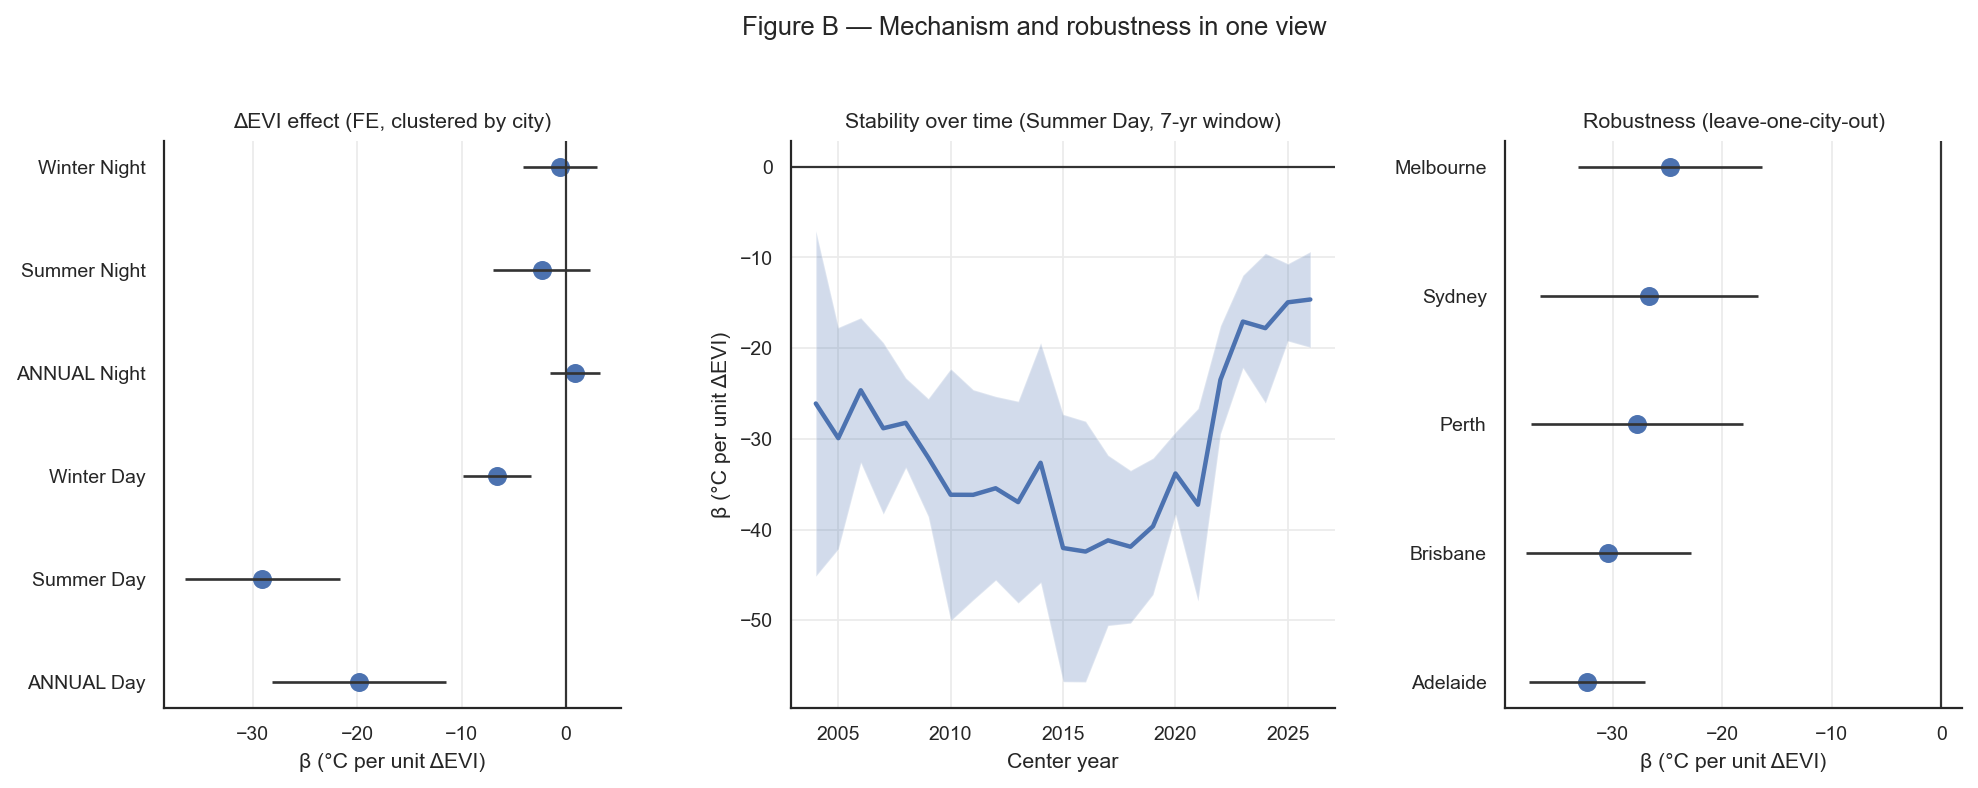

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="white", context="paper")

X_CTRL = ["wind10_ms_mean","rh_pct_mean","cloud_frac_mean","blh_m_mean"]
KEYS = ["city","year","period"]

def fit_fe(df, y):
    d = df.dropna(subset=[y, "dEVI_mean"] + X_CTRL + ["city","year"]).copy()
    m = smf.ols(
        f"{y} ~ dEVI_mean + " + " + ".join(X_CTRL) + " + C(city) + C(year)",
        data=d
    ).fit(cov_type="cluster", cov_kwds={"groups": d["city"]})
    return m, d

# 1) Effect sizes (Annual/DJF/JJA × Day/Night)
rows = []
for p in ["ANNUAL","Summer","Winter"]:
    for lab, y in [("Day", Y_DAY), ("Night", Y_NIGHT)]:
        m, d = fit_fe(panel[panel["period"]==p], y)
        b = m.params["dEVI_mean"]
        se = m.bse["dEVI_mean"]
        rows.append([p, lab, b, b-1.96*se, b+1.96*se, int(m.nobs)])
eff = pd.DataFrame(rows, columns=["period","time","beta","lo","hi","n"])

# 2) Rolling window stability for DJF Day (change window if needed)
def rolling_effect(df, y, window=7):
    out_rows = []
    yrs = sorted(df["year"].unique())
    for y0 in yrs:
        lo = y0 - window//2
        hi = y0 + window//2
        sub = df[(df["year"]>=lo) & (df["year"]<=hi)].copy()
        if sub["year"].nunique() < max(4, window//2):  # avoid too-few years
            continue
        m, d = fit_fe(sub, y)
        b = m.params["dEVI_mean"]
        se = m.bse["dEVI_mean"]
        out_rows.append([y0, b, b-1.96*se, b+1.96*se, int(m.nobs)])
    return pd.DataFrame(out_rows, columns=["year","beta","lo","hi","n"])

roll = rolling_effect(panel[panel["period"]=="Summer"], Y_DAY, window=7)

# 3) Leave-one-city-out for DJF Day
loo_rows = []
base = panel[panel["period"]=="Summer"].copy()
for c in sorted(base["city"].unique()):
    sub = base[base["city"]!=c].copy()
    m, d = fit_fe(sub, Y_DAY)
    b = m.params["dEVI_mean"]
    se = m.bse["dEVI_mean"]
    loo_rows.append([c, b, b-1.96*se, b+1.96*se])
loo = pd.DataFrame(loo_rows, columns=["left_out","beta","lo","hi"])

# ---- Plot composite ----
fig = plt.figure(figsize=(14.5, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.25, 1.05], wspace=0.35)

# Panel 1: effect sizes
ax1 = fig.add_subplot(gs[0,0])
eff2 = eff.copy()
eff2["label"] = eff2["period"] + " " + eff2["time"]
order = ["ANNUAL Day","Summer Day","Winter Day","ANNUAL Night","Summer Night","Winter Night"]
eff2["label"] = pd.Categorical(eff2["label"], order, ordered=True)
eff2 = eff2.sort_values("label")

ax1.hlines(eff2["label"], eff2["lo"], eff2["hi"], color="0.2", lw=1.2)
ax1.scatter(eff2["beta"], eff2["label"], s=60)
ax1.axvline(0, color="0.2", lw=1)
ax1.set_title("ΔEVI effect (FE, clustered by city)")
ax1.set_xlabel("β (°C per unit ΔEVI)")
ax1.set_ylabel("")
ax1.grid(axis="x", color="0.92", lw=0.8)
sns.despine(ax=ax1)

# Panel 2: rolling stability
ax2 = fig.add_subplot(gs[0,1])
ax2.fill_between(roll["year"], roll["lo"], roll["hi"], alpha=0.25)
ax2.plot(roll["year"], roll["beta"], lw=2.0)
ax2.axhline(0, color="0.2", lw=1)
ax2.set_title("Stability over time (Summer Day, 7-yr window)")
ax2.set_xlabel("Center year")
ax2.set_ylabel("β (°C per unit ΔEVI)")
ax2.grid(color="0.92", lw=0.8)
sns.despine(ax=ax2)

# Panel 3: leave-one-city-out
ax3 = fig.add_subplot(gs[0,2])
loo = loo.sort_values("beta")
ax3.hlines(loo["left_out"], loo["lo"], loo["hi"], color="0.2", lw=1.2)
ax3.scatter(loo["beta"], loo["left_out"], s=60)
ax3.axvline(0, color="0.2", lw=1)
ax3.set_title("Robustness (leave-one-city-out)")
ax3.set_xlabel("β (°C per unit ΔEVI)")
ax3.set_ylabel("")
ax3.grid(axis="x", color="0.92", lw=0.8)
sns.despine(ax=ax3)

fig.suptitle("Figure B — Mechanism and robustness in one view", y=1.05)
plt.tight_layout()
savefig(fig, "FigB_effect_stability_robustness")
plt.show()